# 💳🏬 Superstore Korea 2025 - Análisis de Ventas y Tendencias

## 📌 Introducción

El objetivo de este análisis es explorar el comportamiento de ventas, rentabilidad y el impacto de los descuentos en el negocio.

Se utilizará un dataset de ventas que contiene información sobre pedidos, clientes, productos y métricas financieras.

In [2]:
import pandas as pd

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib

In [3]:
data = pd.read_csv("../data/KR_Superstore_sample_2025.csv")
data.head()

,주문 번호,주문 일자,배송 일자,배송 방법,고객번호,고객명,고객 세그먼트,시군구,시도,국가,제품 코드,제품 대분류,제품 중분류,제품명,관리자,반품?,매출,수량,할인율,수익
0,IN-2025-63178,6/24/2025,6/30/2025,표준 배송,SO-20335,강희수,소비자,제주시,제주특별자치도,대한민국,OFF-AP-10002882,사무용품,가전,"KitchenAid Coffee Grinder, Silver",곽승예,False,123495.480,2,0.15,37754.280
1,ID-2025-39084,6/13/2025,6/17/2025,표준 배송,PO-18865,최유미,소비자,울주군,울산광역시,대한민국,TEC-CO-10000666,사무기기,복사기,"Hewlett Copy Machine, Laser",원유선,True,698298.120,4,0.35,-64498.680
2,ID-2025-44908,2/27/2025,3/4/2025,표준 배송,AI-10855,허동춘,소비자,완도군,전라남도,대한민국,OFF-SU-10004848,사무용품,일반 사무용품,"Kleencut Shears, High Speed",곽승예,False,126419.310,5,0.47,-85944.690
3,ID-2025-44908,2/27/2025,3/4/2025,표준 배송,AI-10855,허동춘,소비자,완도군,전라남도,대한민국,OFF-PA-10003332,사무용품,종이,"Xerox Cards & Envelopes, Recycled",곽승예,False,48524.256,2,0.47,-15613.344
4,ID-2025-62926,9/18/2025,9/19/2025,특급 배송,MC-18100,정희성,소비자,서초구,서울특별시,대한민국,TEC-MA-10003553,사무기기,전산기기,"Epson Printer, Red",전소현,False,397448.100,2,0.25,-84807.900


In [4]:
data.columns

Index(['주문 번호', '주문 일자', '배송 일자', '배송 방법', '고객번호', '고객명', '고객 세그먼트', '시군구',
       '시도', '국가', '제품 코드', '제품 대분류', '제품 중분류', '제품명', '관리자', '반품?', '매출',
       '수량', '할인율', '수익'],
      dtype='str')

## 🧼 Limpieza de datos

Se realizaron las siguientes transformaciones:

- Renombrado de columnas
- Traducción de categorías (coreano → inglés)
- Conversión de fechas
- Limpieza de valores en la columna "returned"
- Verificación de valores nulos y duplicados

Los datos se encuentran listos para análisis.

In [5]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 11000 entries, 0 to 10999
Data columns (total 20 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   주문 번호    11000 non-null  str    
 1   주문 일자    11000 non-null  str    
 2   배송 일자    11000 non-null  str    
 3   배송 방법    11000 non-null  str    
 4   고객번호     11000 non-null  str    
 5   고객명      11000 non-null  str    
 6   고객 세그먼트  11000 non-null  str    
 7   시군구      11000 non-null  str    
 8   시도       11000 non-null  str    
 9   국가       11000 non-null  str    
 10  제품 코드    11000 non-null  str    
 11  제품 대분류   11000 non-null  str    
 12  제품 중분류   11000 non-null  str    
 13  제품명      11000 non-null  str    
 14  관리자      11000 non-null  str    
 15  반품?      11000 non-null  str    
 16  매출       11000 non-null  float64
 17  수량       11000 non-null  int64  
 18  할인율      11000 non-null  float64
 19  수익       11000 non-null  float64
dtypes: float64(3), int64(1), str(16)
memory usage: 1.7 MB


In [6]:
# cantidad de valores nulos
data.isnull().sum()

주문 번호      0
주문 일자      0
배송 일자      0
배송 방법      0
고객번호       0
고객명        0
고객 세그먼트    0
시군구        0
시도         0
국가         0
제품 코드      0
제품 대분류     0
제품 중분류     0
제품명        0
관리자        0
반품?        0
매출         0
수량         0
할인율        0
수익         0
dtype: int64

In [7]:
# Total de filas duplicadas
data.duplicated().sum()

np.int64(3)

In [8]:
data.columns = [
    "order_id", "order_date", "ship_date", "ship_mode",
    "customer_id", "customer_name", "segment",
    "city", "state", "country",
    "product_id", "category", "sub_category", "product_name",
    "manager", "returned",
    "sales", "quantity", "discount", "profit"
]

#### 🗂️ Diccionarios 

In [9]:
# Segmentos de cliente
segment_map = {
    "소비자": "Consumer",
    "기업 고객": "Corporate",
    "홈 오피스": "Home Office"
}

data["segment"] = data["segment"].replace(segment_map)

In [10]:
# Metodos de envio 
ship_mode_map = {
    "표준 배송": "Standard Class",
    "특급 배송": "First Class",
    "당일 배송": "Same Day",
    "빠른 배송": "Second Class"
}

data["ship_mode"] = data["ship_mode"].replace(ship_mode_map)

In [11]:
# Categorias 
category_map = {
    "사무용품": "Office Supplies",
    "사무기기": "Technology",
    "가구": "Furniture"
}

data["category"] = data["category"].replace(category_map)

In [12]:
# Subcategorías 
sub_category_map = {
    "가전": "Appliances",
    "복사기": "Copiers",
    "일반 사무용품": "Supplies",
    "종이": "Paper",
    "전산기기": "Machines",
    "탁자": "Tables",
    "필기구": "Art",
    "수납용품": "Storage",
    "의자": "Chairs",
    "바인더": "Binders",
    "가구류": "Furnishings",
    "책장": "Bookcases",
    "봉투": "Envelopes",
    "라벨": "Labels",
    "악세사리": "Accessories",
    "전화기": "Phones",
    "파스너": "Fasteners"
}

data["sub_category"] = data["sub_category"].replace(sub_category_map)

In [13]:
# Valores únicos en cada columna
data["category"].unique()

<StringArray>
['Office Supplies', 'Technology', 'Furniture']
Length: 3, dtype: str

In [14]:
data["segment"].unique()

<StringArray>
['Consumer', 'Corporate', 'Home Office']
Length: 3, dtype: str

In [15]:
data["ship_mode"].unique()

<StringArray>
['Standard Class', 'First Class', 'Same Day', 'Second Class']
Length: 4, dtype: str

In [16]:
data["returned"].unique()

<StringArray>
['False', 'True']
Length: 2, dtype: str

In [17]:
# Resumen estadístico de las columnas numéricas del DataFrame
data.describe()

,sales,quantity,discount,profit
count,1.100000e+04,11000.000000,11000.000000,1.100000e+04
mean,3.324670e+05,3.747455,0.148812,4.043220e+04
std,5.627088e+05,2.257986,0.176358,1.739439e+05
min,2.937600e+03,1.000000,0.000000,-3.069624e+06
25%,4.803366e+04,2.000000,0.000000,-3.055410e+03
50%,1.251509e+05,3.000000,0.100000,1.110780e+04
75%,3.548752e+05,5.000000,0.270000,4.933370e+04
max,7.138613e+06,14.000000,0.800000,2.998096e+06


In [18]:
# Registros con ventas negativas
data[data["sales"] < 0]

,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,city,state,country,product_id,category,sub_category,product_name,manager,returned,sales,quantity,discount,profit


In [19]:
# Registros con descuentos inválidos (menores a 0 o mayores a 1)
data[(data["discount"] < 0) | (data["discount"] > 1)]

,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,city,state,country,product_id,category,sub_category,product_name,manager,returned,sales,quantity,discount,profit


In [20]:
# Limpiar caracteres raros y convertir a booleano
data["returned"] = data["returned"].astype(str).str.replace("\x08", "")
data["returned"] = data["returned"].replace({"True": True, "False": False}).astype(bool)


# Convertir columnas de fecha a tipo datetime
data["order_date"] = pd.to_datetime(data["order_date"])
data["ship_date"] = pd.to_datetime(data["ship_date"])

In [21]:
# Información general del DataFrame
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 11000 entries, 0 to 10999
Data columns (total 20 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   order_id       11000 non-null  str           
 1   order_date     11000 non-null  datetime64[us]
 2   ship_date      11000 non-null  datetime64[us]
 3   ship_mode      11000 non-null  str           
 4   customer_id    11000 non-null  str           
 5   customer_name  11000 non-null  str           
 6   segment        11000 non-null  str           
 7   city           11000 non-null  str           
 8   state          11000 non-null  str           
 9   country        11000 non-null  str           
 10  product_id     11000 non-null  str           
 11  category       11000 non-null  str           
 12  sub_category   11000 non-null  str           
 13  product_name   11000 non-null  str           
 14  manager        11000 non-null  str           
 15  returned       11000 non-null 

In [22]:
# Exportar el DataFrame limpio a un archivo CSV
data.to_csv("kr_superstore_clean.csv", index = False)

## 📊Análisis  

### 📦 Ventas por categoría

Se analizan las ventas totales por categoría de producto.


         Categoría    Ventas (₩)
0        Furniture  1.370495e+09
1  Office Supplies  9.020017e+08
2       Technology  1.384640e+09


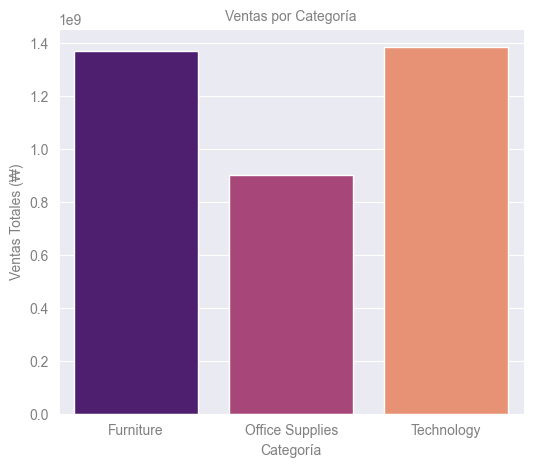

In [23]:
ventas_categoria = data.groupby("category")["sales"].sum().reset_index()
ventas_categoria.columns = ["Categoría", "Ventas (₩)"]
print(ventas_categoria)

# Estilo oscuro
sns.set_style("darkgrid")   # Fondo gris oscuro con cuadrícula
plt.figure(figsize=(6,5))

# Crear el barplot con colores más llamativos sobre fondo oscuro
sns.barplot(
    x="Categoría", 
    y="Ventas (₩)", 
    data=ventas_categoria, 
    hue="Categoría", 
    palette="magma", 
    legend=False
)

# Títulos y etiquetas
plt.title("Ventas por Categoría", fontsize=10, color="gray")
plt.xlabel("Categoría", color="gray")
plt.ylabel("Ventas Totales (₩)", color="gray")

# Cambiar color de los ejes a blanco para que se vean en fondo oscuro
plt.tick_params(colors="gray")
plt.show()

**Insight:**  
Office Supplies es la categoría con mayor volumen de ventas, lo que indica alta demanda, pero no necesariamente alta rentabilidad.

### 💰 Rentabilidad por categoría

Se evalúa qué categorías generan mayor ganancia.

In [24]:
# Profit por categoría
profit_por_categoria = data.groupby("category")["profit"].sum().reset_index()
print(profit_por_categoria)

          category        profit
0        Furniture  1.284458e+08
1  Office Supplies  1.076227e+08
2       Technology  2.086857e+08


**Insight:**  
**Technology** es la categoría más rentable, lo que sugiere mejores márgenes de ganancia.

### ⚠️ Impacto del descuento en la rentabilidad

    discount         profit
0       0.00   91301.564206
1       0.07  143809.822440
2       0.10   56329.599546
3       0.15   15913.847195
4       0.17   39083.449494
5       0.20   14398.563913
6       0.25    4124.238636
7       0.27   -4403.556881
8       0.30 -140795.387419
9       0.35  -66856.410000
10      0.37  -80031.434351
11      0.40  -52228.681685
12      0.45  -32518.137611
13      0.47  -43842.068541
14      0.50  -89546.606459
15      0.55 -321368.544000
16      0.57 -536651.580000
17      0.60 -159709.560000
18      0.80 -698159.029091


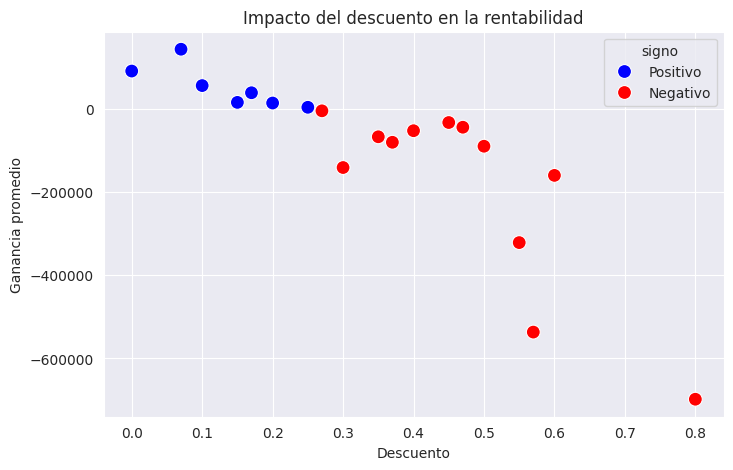

In [36]:
# Impacto del descuento
impacto_de_descuento = data.groupby("discount")["profit"].mean().reset_index()
print(impacto_de_descuento)

# Crear columna auxiliar para clasificar positivo/negativo
impacto_de_descuento["signo"] = impacto_de_descuento["profit"].apply(lambda x: "Negativo" if x < 0 else "Positivo")

plt.figure(figsize=(8,5))
sns.scatterplot(data=impacto_de_descuento, x="discount", y="profit", 
                hue="signo", palette={"Positivo":"blue", "Negativo":"red"}, s=100)

plt.title("Impacto del descuento en la rentabilidad")
plt.xlabel("Descuento")
plt.ylabel("Ganancia promedio")
plt.grid(True)
plt.show()

**Insight:**  
Existe una relación negativa entre descuento y rentabilidad: a partir de ~27% de descuento, los productos comienzan a generar pérdidas.

### 🌍 Ventas por región

Se identifican las regiones con mayor volumen de ventas.

   state         sales
0  서울특별시  8.094339e+08
1    경기도  7.334132e+08
2  부산광역시  2.510648e+08
3  울산광역시  2.139235e+08
4   충청남도  1.900570e+08
5  인천광역시  1.861115e+08
6   경상북도  1.630900e+08
7   전라남도  1.600956e+08
8    강원도  1.447182e+08
9  대구광역시  1.402830e+08


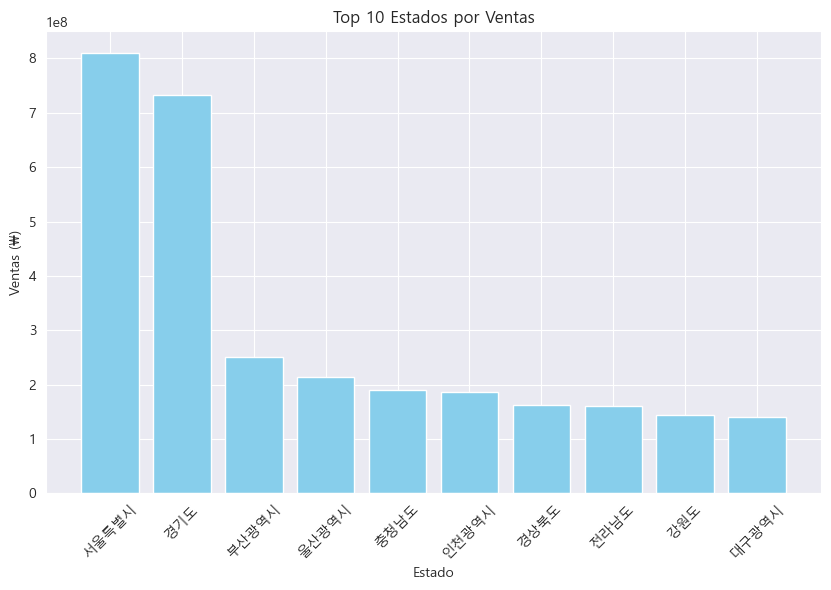

In [26]:
# Ventas por region
ventas_region = data.groupby("state")["sales"].sum().sort_values(ascending=False).head(10).reset_index()
print(ventas_region)

# Cambiar la fuente a Malgun Gothic (Windows)
matplotlib.rcParams['font.family'] = 'Malgun Gothic'

plt.figure(figsize=(10,6))
plt.bar(ventas_region["state"], ventas_region["sales"], color="skyblue")
plt.xticks(rotation=45)
plt.xlabel("Estado")
plt.ylabel("Ventas (₩)")
plt.title("Top 10 Estados por Ventas")
plt.show()



**Insight:**  
Las regiones como 서울특별시 (Seúl) y 경기도 (Gyeonggi) concentran la mayor parte de las ventas, lo que indica mercados clave.

### 📅 Ventas por mes

Se analiza la evolución de las ventas a lo largo del tiempo.

   order_date         sales
0     2025-11  1.589140e+08
1     2025-10  1.450589e+08
2     2024-06  1.373505e+08
3     2025-08  1.258889e+08
4     2025-12  1.236936e+08
5     2024-08  1.156490e+08
6     2025-09  1.141798e+08
7     2025-06  1.102270e+08
8     2025-05  1.031212e+08
9     2023-10  1.028549e+08
10    2024-09  1.002524e+08
11    2024-12  9.932643e+07
12    2024-10  9.880059e+07
13    2022-12  9.554427e+07
14    2023-08  9.336558e+07
15    2023-12  9.090785e+07
16    2024-05  8.963521e+07
17    2024-11  8.819458e+07
18    2025-03  8.591704e+07
19    2023-11  8.548861e+07
20    2022-11  8.330439e+07
21    2022-10  7.962227e+07
22    2023-06  7.907784e+07
23    2025-01  7.868534e+07
24    2025-07  7.049425e+07
25    2024-01  6.807080e+07
26    2023-05  6.780701e+07
27    2024-07  6.649865e+07
28    2022-06  6.542227e+07
29    2022-08  6.210502e+07
30    2023-09  6.194430e+07
31    2022-09  6.161991e+07
32    2025-04  6.122472e+07
33    2025-02  5.907118e+07
34    2024-03  5.233

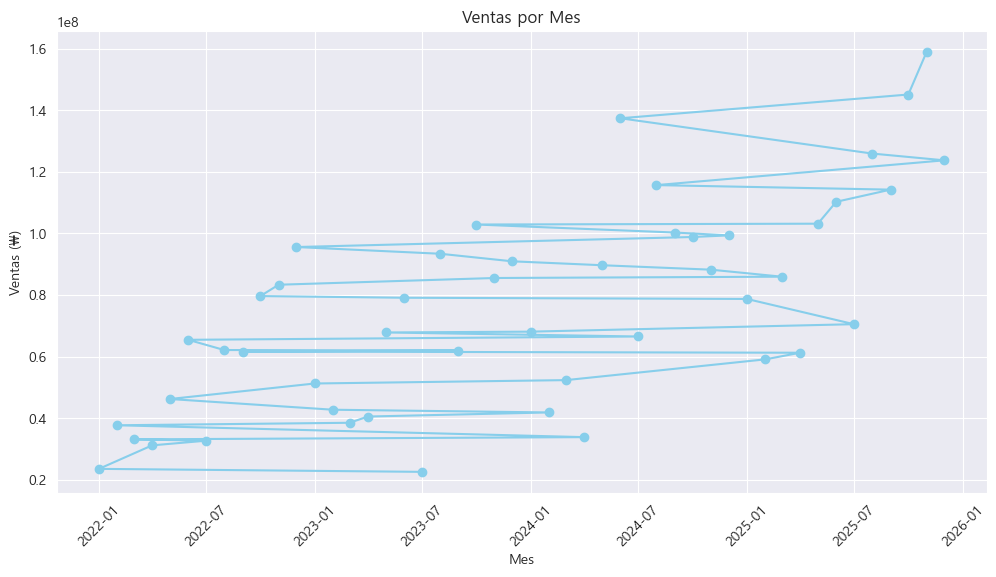

In [27]:
# Ventas por mes
ventas_mes = data.groupby(data["order_date"].dt.to_period("M"))["sales"].sum().sort_values(ascending=False).reset_index()
print(ventas_mes)

# Visualización
ventas_mes["order_date"] = ventas_mes["order_date"].dt.to_timestamp()
plt.figure(figsize=(12,6))
plt.plot(ventas_mes["order_date"], ventas_mes["sales"], marker="o", linestyle="-", color="skyblue")
plt.xticks(rotation=45)
plt.xlabel("Mes")
plt.ylabel("Ventas (₩)")
plt.title("Ventas por Mes")
plt.grid(True)
plt.show()

**Insight:**  
Las ventas muestran estacionalidad, con picos en junio, agosto, octubre y noviembre.

### 💰Top 10, productos más rentables

                                        product_name       profit
1285                 Motorola Smart Phone, Full Size  7769306.340
1392   Office Star Executive Leather Armchair, Black  6245720.406
1562                       Samsung Smart Phone, VoIP  5463942.120
1309               Nokia Smart Phone, with Caller ID  5382581.004
1326  Novimex Executive Leather Armchair, Adjustable  5148875.952
1641                  Sauder Classic Bookcase, Metal  4956618.600
949                      Hewlett Wireless Fax, Color  4951349.280
1644            Sauder Classic Bookcase, Traditional  4904898.480
157                Apple Smart Phone, with Caller ID  4836121.920
510                Cisco Smart Phone, with Caller ID  4564313.136


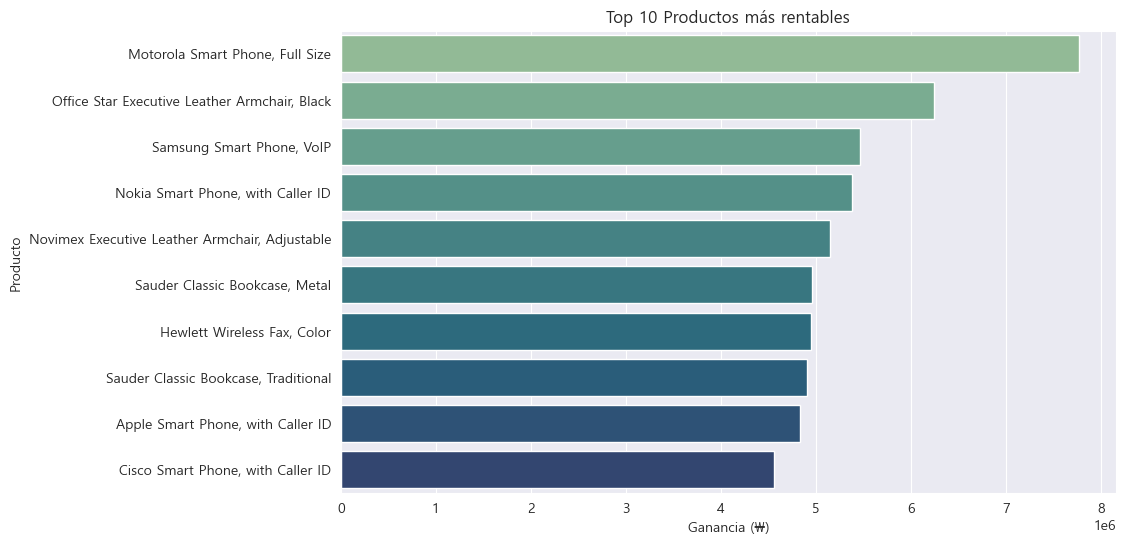

In [28]:
profit_por_producto = data.groupby("product_name")["profit"].sum().reset_index()
profit_por_producto = profit_por_producto.sort_values(by="profit", ascending=False)
top10_rentables = profit_por_producto.head(10)
print(top10_rentables)

plt.figure(figsize=(10,6))
sns.barplot(
    x="profit", 
    y="product_name",
    hue="product_name",
    data=top10_rentables, 
    palette="crest",
    legend=False 
)
plt.xlabel("Ganancia (₩)")
plt.ylabel("Producto")
plt.title("Top 10 Productos más rentables")
plt.show()

### 🔻 Top 10, productos con perdidas

In [29]:
profit_por_producto = data.groupby("product_name")["profit"].sum().reset_index()
profit_por_producto = profit_por_producto.sort_values(by="profit", ascending=True)
top10_perdidas = profit_por_producto.head(10)

print(top10_perdidas)


                                  product_name       profit
156               Apple Smart Phone, Full Size -2793906.378
972          Hon Conference Table, Rectangular -2615453.910
290      Bevis Wood Table, with Bottom Storage -2330085.960
345                 Breville Microwave, Silver -1962513.864
484    Chromcraft Round Table, Fully Assembled -1888206.660
1215         Lesro Training Table, Rectangular -1760653.008
1080      Ikea Library with Doors, Traditional -1672060.500
974      Hon Executive Leather Armchair, Black -1661166.288
1213   Lesro Training Table, Adjustable Height -1628406.234
236   Barricks Computer Table, Fully Assembled -1462353.804


###  🔄 Tasa de devoluciones

In [30]:
tasa_devoluciones = data["returned"].mean()
print("Tasa de devoluciones:", tasa_devoluciones)


Tasa de devoluciones: 0.07136363636363637


#### ↩️ Devoluciones por categoría

In [31]:
tasa_categoria = data.groupby("category")["returned"].mean().reset_index()
print(tasa_categoria)

          category  returned
0        Furniture  0.076194
1  Office Supplies  0.069139
2       Technology  0.072204


#### ↩️ Devoluciones vs descuento

In [32]:
devoluciones_descuento = data.groupby("discount")["returned"].mean().reset_index()
print(devoluciones_descuento)

    discount  returned
0       0.00  0.102602
1       0.07  0.086667
2       0.10  0.045393
3       0.15  0.036585
4       0.17  0.043537
5       0.20  0.076087
6       0.25  0.055556
7       0.27  0.041237
8       0.30  0.080645
9       0.35  0.012987
10      0.37  0.040541
11      0.40  0.029494
12      0.45  0.044586
13      0.47  0.048276
14      0.50  0.091314
15      0.55  0.100000
16      0.57  0.083333
17      0.60  0.000000
18      0.80  0.000000


**Insight:**  
La tasa de devoluciones es de 7.13%, lo que se considera un nivel moderado dentro del sector retail.
Sin embargo, las devoluciones pueden afectar significativamente la rentabilidad, especialemnte en productos con altos descuentos. 

### 🧠 Conclusiones

- La categoría más importante en ventas es Office Supplies
- La categoría más rentable es Technology
- Los descuentos altos generan pérdidas significativas
- Existen regiones clave que concentran la mayor parte de las ventas

Este análisis sugiere que la empresa debería revisar su estrategia de descuentos para mejorar la rentabilidad.

### 💡 Recomendaciones
- Revisar la política de descuentos en *Office Supplies*.  
- Potenciar la categoría *Technology* por su alta rentabilidad.  
- Optimizar logística en *Furniture*.  
- Expandir presencia en regiones con menor participación.  



### 📂 Dataset
Este notebook utiliza el dataset **KR Superstore Sample 2025**, disponible en Kaggle:  
https://www.kaggle.com/datasets/heoquixote/krsuperstore-sample-2025  

Licencia: Creative Commons Attribution 4.0 International (CC BY 4.0).
Autor: heoquixote
